# Projeto Final - Análise de Score de Crédito

## Missão 3 - Entendendo o Dataset

### Objetivo

Nesta etapa iremos:

- importar o dataset;
- conhecer sua estrutura;
- identificar possíveis inconsistências;
- preparar o entendimento dos dados antes da limpeza.

In [336]:
import pandas as pd


In [337]:
df = pd.read_csv('/content/train.csv')

/tmp/ipykernel_1316/1934789371.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/train.csv')


In [338]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [339]:
df.shape

(100000, 28)

In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [341]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [342]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [343]:
df['Customer_ID'].nunique()

12500

In [344]:
df['Month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August'], dtype=object)

In [345]:
df['Month'].value_counts()

,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500


# Conclusão da Etapa 1 - Leitura e Exploração Inicial

Nesta etapa foi realizada a leitura do dataset `train.csv` e a exploração inicial dos dados.

Principais descobertas:

- O dataset possui 100.000 registros e 28 colunas.
- Existem 12.500 clientes únicos.
- Cada cliente possui registros distribuídos ao longo de 8 meses (janeiro a agosto).
- Foram identificados valores ausentes em algumas colunas.
- Também foram observados valores aparentemente inconsistentes, que serão investigados na etapa de limpeza.


####DIAGNOSTICANDO A LIMPEZA DO DATASET

In [346]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [347]:
df.duplicated().sum()

np.int64(0)

In [348]:
df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x25fd5,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [349]:
df.isnull().sum().sort_values(ascending=False)

,0
Monthly_Inhand_Salary,15002
Type_of_Loan,11408
Name,9985
Credit_History_Age,9030
Num_of_Delayed_Payment,7002
Amount_invested_monthly,4479
Num_Credit_Inquiries,1965
Monthly_Balance,1200
Month,0
Age,0


In [350]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Monthly_Inhand_Salary,15.002
Type_of_Loan,11.408
Name,9.985
Credit_History_Age,9.030
Num_of_Delayed_Payment,7.002
Amount_invested_monthly,4.479
Num_Credit_Inquiries,1.965
Monthly_Balance,1.200
Month,0.000
Age,0.000


In [351]:
df.duplicated().sum()

np.int64(0)

### Tratamento da variável Age

Durante a exploração inicial foram identificados caracteres inválidos (`_`) e valores incompatíveis com o contexto de análise de crédito, como `-500`, `181`, `1342` e `7580`.

Inicialmente, os caracteres especiais foram removidos da coluna e, posteriormente, foi adotada como premissa de negócio a consideração de clientes entre 18 e 90 anos.

Registros fora desse intervalo foram considerados inconsistentes e removidos da análise.

In [352]:
df['Age'].describe()

,Age
count,100000
unique,1788
top,38
freq,2833


In [353]:
df['Age'].unique()[:20]

array(['23', '-500', '28_', '28', '34', '54', '55', '21', '31', '33',
       '34_', '7580', '30', '30_', '24', '24_', '44', '45', '40', '41'],
      dtype=object)

In [354]:
df[df['Age'].str.contains('_', na=False)].shape

(4939, 28)

In [355]:
df[df['Age'].astype(str).str.contains('-', na=False)].shape

(886, 28)

In [356]:
df[df['Age'].astype(str).str.len() > 3].shape

(2580, 28)

In [357]:
df_clean = df.copy()

In [358]:
df_clean['Age'] = df_clean['Age'].str.replace('_', '', regex=False)

In [359]:
df_clean['Age'].unique()[:20]

array(['23', '-500', '28', '34', '54', '55', '21', '31', '33', '7580',
       '30', '24', '44', '45', '40', '41', '32', '35', '36', '39'],
      dtype=object)

In [360]:
df_clean[(df_clean['Age'].astype(int) < 18) | (df_clean['Age'].astype(int) > 100)].shape

(8482, 28)

In [361]:
df_clean[(df_clean['Age'].astype(int) < 18) | (df_clean['Age'].astype(int) > 100)]['Age'].unique()

array(['-500', '7580', '181', ..., '4808', '2263', '1342'], dtype=object)

In [362]:
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

df_clean = df_clean[
    (df_clean['Age'] >= 18) &
    (df_clean['Age'] <= 90)
]

In [363]:
df_clean.shape

(91513, 28)

A variável Monthly_Inhand_Salary apresentava aproximadamente 15% de valores ausentes. Considerando a assimetria da distribuição salarial observada pela diferença entre média e mediana, optou-se pela imputação utilizando a mediana da variável, reduzindo o impacto de possíveis outliers na análise.

In [364]:
df_clean['Monthly_Inhand_Salary'].describe()

,Monthly_Inhand_Salary
count,77805.000000
mean,4256.483911
std,3218.977468
min,303.645417
25%,1646.647917
50%,3133.327500
75%,6061.705000
max,15204.633333


In [365]:
mediana_salario = df_clean['Monthly_Inhand_Salary'].median()

df_clean['Monthly_Inhand_Salary'] = (
    df_clean['Monthly_Inhand_Salary']
    .fillna(mediana_salario)
)

In [366]:
df_clean['Monthly_Inhand_Salary'].isnull().sum()

np.int64(0)

A variável Credit_History_Age encontrava-se em formato textual (X Years and Y Months). Para facilitar a análise e visualização, foi convertida para anos inteiros utilizando arredondamento convencional, considerando meses inferiores a 6 para arredondamento para baixo e meses iguais ou superiores a 6 para arredondamento para cima.

In [367]:
df_clean['Credit_History_Age'].head()

,Credit_History_Age
0,22 Years and 1 Months
1,NaN
3,22 Years and 4 Months
4,22 Years and 5 Months
5,22 Years and 6 Months


In [368]:
df_clean['Credit_History_Age'].describe()

,Credit_History_Age
count,83217
unique,404
top,15 Years and 11 Months
freq,417


In [369]:
df_clean['Credit_History_Years'] = (
    df_clean['Credit_History_Age']
    .str.extract(r'(\d+) Years')
)

In [370]:
df_clean['Credit_History_Months'] = (
    df_clean['Credit_History_Age']
    .str.extract(r'and (\d+) Months')
)

In [371]:
df_clean['Credit_History_Years'] = pd.to_numeric(
    df_clean['Credit_History_Years'],
    errors='coerce'
)

df_clean['Credit_History_Months'] = pd.to_numeric(
    df_clean['Credit_History_Months'],
    errors='coerce'
)

In [372]:
df_clean['Credit_History_Age_Clean'] = (
    df_clean['Credit_History_Years'] +
    (df_clean['Credit_History_Months'] >= 6).astype(int)
)

In [373]:
df_clean[
    [
        'Credit_History_Age',
        'Credit_History_Years',
        'Credit_History_Months',
        'Credit_History_Age_Clean'
    ]
].head(10)

,Credit_History_Age,Credit_History_Years,Credit_History_Months,Credit_History_Age_Clean
0,22 Years and 1 Months,22.0,1.0,22.0
1,NaN,NaN,NaN,NaN
3,22 Years and 4 Months,22.0,4.0,22.0
4,22 Years and 5 Months,22.0,5.0,22.0
5,22 Years and 6 Months,22.0,6.0,23.0
6,22 Years and 7 Months,22.0,7.0,23.0
7,NaN,NaN,NaN,NaN
8,26 Years and 7 Months,26.0,7.0,27.0
9,26 Years and 8 Months,26.0,8.0,27.0
10,26 Years and 9 Months,26.0,9.0,27.0


In [374]:
df_clean['Credit_History_Age_Clean'].median()

19.0

In [375]:
df_clean['Credit_History_Age_Clean'] = (
    df_clean['Credit_History_Age_Clean']
    .fillna(
        df_clean['Credit_History_Age_Clean'].median()
    )
)

In [376]:
df_clean['Credit_History_Age_Clean'].isnull().sum()

np.int64(0)

Num_of_Delayed_Payment

In [377]:
df_clean['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,85054
unique,703
top,19
freq,4864


In [378]:
df_clean['Num_of_Delayed_Payment'].unique()[:20]

array(['7', nan, '4', '8_', '6', '1', '-1', '3_', '0', '8', '5', '3', '9',
       '12', '15', '17', '10', '2', '2_', '14'], dtype=object)

In [379]:
df_clean['Num_of_Delayed_Payment'] = (
    df_clean['Num_of_Delayed_Payment']
    .str.replace('_', '', regex=False)
)

In [380]:
df_clean['Num_of_Delayed_Payment'] = pd.to_numeric(
    df_clean['Num_of_Delayed_Payment'],
    errors='coerce'
)

In [381]:
df_clean.loc[
    df_clean['Num_of_Delayed_Payment'] < 0,
    'Num_of_Delayed_Payment'
] = None

In [382]:
df_clean['Num_of_Delayed_Payment'] = (
    df_clean['Num_of_Delayed_Payment']
    .fillna(
        df_clean['Num_of_Delayed_Payment'].median()
    )
)

In [383]:
df_clean['Num_of_Delayed_Payment'].isnull().sum()

np.int64(0)

In [384]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
Type_of_Loan,10920
Name,9177
Credit_History_Age,8296
Credit_History_Months,8296
Credit_History_Years,8296
Amount_invested_monthly,4086
Num_Credit_Inquiries,1793
Monthly_Balance,1085
Annual_Income,0
Occupation,0


In [385]:
df_clean['Type_of_Loan'] = df_clean['Type_of_Loan'].fillna('Unknown')

In [386]:
df_clean['Amount_invested_monthly'].dtype

dtype('O')

In [387]:
df_clean['Amount_invested_monthly'].unique()[:20]

array(['80.41529543900253', '118.28022162236736', '199.4580743910713',
       '41.420153086217326', '62.430172331195294', '178.3440674122349',
       '24.785216509052056', '104.291825168246', '40.39123782853101',
       '58.51597569589465', '99.30622796053305', '130.11542024292334',
       '43.477190144355745', '70.10177420755677', '218.90434353388733',
       '168.413702679309', '232.86038375993544', '__10000__',
       '825.2162699393922', '430.9475278803298'], dtype=object)

In [388]:
df_clean['Amount_invested_monthly'] = (
    df_clean['Amount_invested_monthly']
    .str.replace('_', '', regex=False)
)

In [389]:
df_clean['Amount_invested_monthly'] = pd.to_numeric(
    df_clean['Amount_invested_monthly'],
    errors='coerce'
)

In [390]:
df_clean['Amount_invested_monthly'] = (
    df_clean['Amount_invested_monthly']
    .fillna(
        df_clean['Amount_invested_monthly'].median()
    )
)

In [391]:
df_clean['Amount_invested_monthly'].isnull().sum()

np.int64(0)

In [392]:
df_clean['Amount_invested_monthly'].isnull().sum()

np.int64(0)

In [393]:
df_clean['Num_Credit_Inquiries'].unique()[:20]

array([4.000e+00, 2.000e+00, 3.000e+00,       nan, 5.000e+00, 9.000e+00,
       8.000e+00, 7.000e+00, 6.000e+00, 0.000e+00, 1.000e+00, 1.000e+01,
       1.050e+03, 1.100e+01, 1.200e+01, 1.044e+03, 1.700e+01, 1.936e+03,
       1.300e+01, 5.680e+02])

In [394]:
df_clean['Monthly_Balance'].describe()

,Monthly_Balance
count,90428
unique,90421
top,__-333333333333333333333333333__
freq,8


In [395]:
df_clean['Type_of_Loan'] = (
    df_clean['Type_of_Loan']
    .fillna('Unknown')
)

In [396]:
df_clean[df_clean['Num_Credit_Inquiries'] > 100].shape

(1469, 31)

In [397]:
df_clean.loc[
    df_clean['Num_Credit_Inquiries'] > 100,
    'Num_Credit_Inquiries'
] = None

In [398]:
df_clean['Num_Credit_Inquiries'] = (
    df_clean['Num_Credit_Inquiries']
    .fillna(
        df_clean['Num_Credit_Inquiries'].median()
    )
)

In [399]:
df_clean['Num_Credit_Inquiries'].isnull().sum()

np.int64(0)

In [400]:
df_clean['Monthly_Balance'].unique()[:20]

array(['312.49408867943663', '284.62916249607184', '223.45130972736786',
       '341.48923103222177', '340.4792117872438', '244.5653167062043',
       '358.12416760938714', '470.69062692529184', '484.5912142650067',
       '466.46647639764313', '465.6762241330048', '444.8670318506144',
       '481.505261949182', '464.8806778859809', '356.07810855965045',
       '1043.3159778669492', '998.8692967863226', '715.741367403555',
       '426.5134106068658', '810.7821526659284'], dtype=object)

In [401]:
df_clean['Monthly_Balance'].dtype

dtype('O')

In [402]:
df_clean['Monthly_Balance'].unique()[:20]

array(['312.49408867943663', '284.62916249607184', '223.45130972736786',
       '341.48923103222177', '340.4792117872438', '244.5653167062043',
       '358.12416760938714', '470.69062692529184', '484.5912142650067',
       '466.46647639764313', '465.6762241330048', '444.8670318506144',
       '481.505261949182', '464.8806778859809', '356.07810855965045',
       '1043.3159778669492', '998.8692967863226', '715.741367403555',
       '426.5134106068658', '810.7821526659284'], dtype=object)

In [403]:
df_clean[
    df_clean['Monthly_Balance'].astype(str).str.contains('_', na=False)
]['Monthly_Balance'].unique()

array(['__-333333333333333333333333333__'], dtype=object)

In [404]:
df_clean['Monthly_Balance'] = (
    df_clean['Monthly_Balance']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [405]:
df_clean['Monthly_Balance'] = pd.to_numeric(
    df_clean['Monthly_Balance'],
    errors='coerce'
)

In [406]:
df_clean['Monthly_Balance'].describe()

,Monthly_Balance
count,9.042800e+04
mean,-2.948939e+22
std,3.135129e+24
min,-3.333333e+26
25%,2.719160e+02
50%,3.402327e+02
75%,4.778486e+02
max,1.602041e+03


In [407]:
df_clean.loc[
    df_clean['Monthly_Balance'] < -100000,
    'Monthly_Balance'
] = None

In [408]:
df_clean.loc[
    df_clean['Monthly_Balance'] < 0,
    'Monthly_Balance'
] = None

In [409]:
df_clean[df_clean['Monthly_Balance'] < 0].shape

(0, 31)

In [410]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
Name,9177
Credit_History_Months,8296
Credit_History_Age,8296
Credit_History_Years,8296
Monthly_Balance,1093
Customer_ID,0
ID,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [411]:
df_clean.loc[
    df_clean['Monthly_Balance'] < 0,
    'Monthly_Balance'
] = None

In [412]:
df_clean['Monthly_Balance'] = (
    df_clean['Monthly_Balance']
    .fillna(
        df_clean['Monthly_Balance'].median()
    )
)

In [413]:
df_clean['Monthly_Balance'].isnull().sum()

np.int64(0)

In [414]:
colunas_remover = [
    'Credit_History_Age',
    'Credit_History_Years',
    'Credit_History_Months'
]

df_clean = df_clean.drop(columns=colunas_remover)

In [415]:
df_clean = df_clean.drop(columns=['Name'])

In [416]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


In [417]:
df_clean.shape

(91513, 27)

In [418]:
df_clean['Name'] = df['Name']

In [419]:
df_clean[['Name']].head()

,Name
0,Aaron Maashoh
1,Aaron Maashoh
3,Aaron Maashoh
4,Aaron Maashoh
5,Aaron Maashoh


EDA

In [420]:
df_clean['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,48782
Poor,25640
Good,17091


In [421]:
(df_clean['Credit_Score'].value_counts(normalize=True) * 100).round(2)

,proportion
Credit_Score,
Standard,53.31
Poor,28.02
Good,18.68


Qual perfil apresenta maior risco de inadimplência?

In [422]:
df_clean[
    [
        'Monthly_Inhand_Salary',
        'Num_of_Delayed_Payment',
        'Num_Credit_Inquiries',
        'Outstanding_Debt',
        'Credit_History_Age_Clean',
        'Num_of_Loan'
    ]
].dtypes

,0
Monthly_Inhand_Salary,float64
Num_of_Delayed_Payment,float64
Num_Credit_Inquiries,float64
Outstanding_Debt,object
Credit_History_Age_Clean,float64
Num_of_Loan,object


In [423]:
df_clean['Outstanding_Debt'].unique()[:20]

array(['809.98', '605.03', '1303.01', '632.46', '943.86', '548.2',
       '352.16', '1704.18', '1377.74', '421.43', '1328.93', '1328.93_',
       '950.36', '179.22', '2602.69', '758.44', '818.22', '1296.64',
       '1283.37', '1283.37_'], dtype=object)

In [424]:
df_clean['Outstanding_Debt'] = (
    df_clean['Outstanding_Debt']
    .astype(str)
    .str.replace('_', '', regex=False)
)

df_clean['Outstanding_Debt'] = pd.to_numeric(
    df_clean['Outstanding_Debt'],
    errors='coerce'
)

In [425]:
df_clean['Num_of_Loan'] = (
    df_clean['Num_of_Loan']
    .astype(str)
    .str.replace('_', '', regex=False)
)

df_clean['Num_of_Loan'] = pd.to_numeric(
    df_clean['Num_of_Loan'],
    errors='coerce'
)

In [426]:
df_clean['Outstanding_Debt'].isnull().sum()

np.int64(0)

In [427]:
df_clean['Num_of_Loan'].isnull().sum()

np.int64(0)

In [428]:
df_clean['Outstanding_Debt'] = (
    df_clean['Outstanding_Debt']
    .fillna(
        df_clean['Outstanding_Debt'].median()
    )
)

In [429]:
df_clean.groupby('Credit_Score')[
    [
        'Monthly_Inhand_Salary',
        'Num_of_Delayed_Payment',
        'Num_Credit_Inquiries',
        'Outstanding_Debt',
        'Credit_History_Age_Clean',
        'Num_of_Loan'
    ]
].mean().round(2)

,Monthly_Inhand_Salary,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_History_Age_Clean,Num_of_Loan
Credit_Score,,,,,,
Good,5048.23,25.03,3.33,791.91,23.40,1.69
Poor,3392.75,31.68,7.92,2049.71,14.89,3.73
Standard,4117.46,30.49,5.17,1246.52,19.32,2.73


In [430]:
df_clean.groupby('Credit_Score')[
    'Num_of_Delayed_Payment'
].describe()

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17091.0,25.029197,209.928544,0.0,5.0,9.0,14.0,4360.0
Poor,25640.0,31.680811,219.563918,0.0,12.0,16.0,20.0,4340.0
Standard,48782.0,30.489853,221.411098,0.0,10.0,14.0,18.0,4397.0


In [431]:
df_clean[df_clean['Num_of_Delayed_Payment'] > 100].shape

(672, 28)

In [432]:
df_clean.loc[
    df_clean['Num_of_Delayed_Payment'] > 100,
    'Num_of_Delayed_Payment'
] = None

In [433]:
df_clean['Num_of_Delayed_Payment'] = (
    df_clean['Num_of_Delayed_Payment']
    .fillna(
        df_clean['Num_of_Delayed_Payment'].median()
    )
)

In [434]:
df_clean.groupby('Credit_Score')[
    'Num_of_Delayed_Payment'
].describe()

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17091.0,9.174712,5.461393,0.0,5.0,9.0,14.0,86.0
Poor,25640.0,15.558892,5.956887,0.0,12.0,16.0,20.0,85.0
Standard,48782.0,13.515600,5.426210,0.0,10.0,14.0,17.0,98.0


In [435]:
df_clean['Annual_Income'].dtype

dtype('O')

In [436]:
df_clean['Annual_Income'].dtype

dtype('O')

In [437]:
df_clean['Annual_Income'] = (
    df_clean['Annual_Income']
    .astype(str)
    .str.replace('_', '', regex=False)
)

df_clean['Annual_Income'] = pd.to_numeric(
    df_clean['Annual_Income'],
    errors='coerce'
)

In [438]:
df_clean['Annual_Income'].isnull().sum()

np.int64(0)

In [439]:
df_clean['Annual_Income'] = (
    df_clean['Annual_Income']
    .fillna(
        df_clean['Annual_Income'].median()
    )
)

In [440]:
df_clean.groupby('Credit_Score')[
    [
        'Annual_Income',
        'Num_Bank_Accounts',
        'Num_Credit_Card',
        'Num_of_Loan'
    ]
].mean().round(2)

,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan
Credit_Score,,,,
Good,185793.08,15.12,21.28,1.69
Poor,155239.92,18.91,23.50,3.73
Standard,187738.52,17.12,22.09,2.73


In [441]:
df_clean.dtypes

,0
ID,object
Customer_ID,object
Month,object
Age,int64
SSN,object
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64


In [442]:
df_clean.select_dtypes(include=['object']).columns

Index(['ID', 'Customer_ID', 'Month', 'SSN', 'Occupation', 'Type_of_Loan',
       'Changed_Credit_Limit', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score', 'Name'],
      dtype='object')

In [443]:
df_clean['Changed_Credit_Limit'].unique()[:20]

array(['11.27', '6.27', '9.27', '5.42', '7.42', '6.42', '7.1', '11.1',
       '9.1', '1.99', '-2.01', '-1.01', '-3.01', '2.58', '10.14', '9.14',
       '9.34', '15.34', '8.34', '11.34'], dtype=object)

In [444]:
df_clean['Changed_Credit_Limit'].describe()

,Changed_Credit_Limit
count,91513
unique,4337
top,_
freq,1910


In [445]:
df_clean['Changed_Credit_Limit'] = (
    df_clean['Changed_Credit_Limit']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [446]:
df_clean['Changed_Credit_Limit'] = pd.to_numeric(
    df_clean['Changed_Credit_Limit'],
    errors='coerce'
)

In [447]:
df_clean['Changed_Credit_Limit'].isnull().sum()

np.int64(1910)

In [448]:
df_clean['Changed_Credit_Limit'] = (
    df_clean['Changed_Credit_Limit']
    .fillna(
        df_clean['Changed_Credit_Limit'].median()
    )
)

In [449]:
df_clean['Changed_Credit_Limit'].dtype

dtype('float64')

EDA APÓS O TRATAMENTO FINAL


In [450]:
df_clean['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,48782
Poor,25640
Good,17091


Distribuição do Score de Crédito

Score	Clientes	Participação

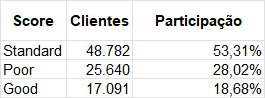

Interpretação

1. A maior parte da base possui score intermediário

Mais da metade dos clientes estão classificados como: Standart

2. Quase 3 em cada 10 clientes apresentam alto risco
Sendo em porcentagem, 28,02% e dos clientes possuem score poor

3. Clientes de baixo risco representam menos de 20%: apenas 18,68% dos clientes estão classificados como: good



In [451]:
df_clean.groupby('Credit_Score')[
    [
        'Monthly_Inhand_Salary',
        'Num_of_Delayed_Payment',
        'Num_Credit_Inquiries',
        'Outstanding_Debt',
        'Credit_History_Age_Clean',
        'Num_of_Loan'
    ]
].mean().round(2)

,Monthly_Inhand_Salary,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_History_Age_Clean,Num_of_Loan
Credit_Score,,,,,,
Good,5048.23,9.17,3.33,791.91,23.40,1.69
Poor,3392.75,15.56,7.92,2049.71,14.89,3.73
Standard,4117.46,13.52,5.17,1246.52,19.32,2.73


Perfil dos clientes por Score

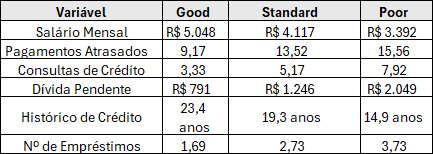

Pergunta 1: Qual perfil tem maior risco de inadimplência?

Menor renda;

Mais atrasos;

Mais consultas de crédito;

Maior dívida;

Menor histórico de crédito;

Maior qtd de empréstimos.

Pergunta 2: O que mais influencia clientes Poor?

Analisando, identifiquei que uma das possíveis influências são dívidas pendentes, ou seja (outstanding_deb), sendo que good -> R$ 791 e Poor -> 2.049 a dívida acaba se tornando 2 vezes maior, o número de empréstimos também sobe além da consulta de créditos ser maior tbm

In [452]:
df_clean.groupby('Credit_Score')[
    [
        'Annual_Income',
        'Num_Bank_Accounts',
        'Num_Credit_Card',
        'Num_of_Loan'
    ]
].mean().round(2)

,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan
Credit_Score,,,,
Good,185793.08,15.12,21.28,1.69
Poor,155239.92,18.91,23.50,3.73
Standard,187738.52,17.12,22.09,2.73


In [453]:
df_clean.groupby('Credit_Score')[
    'Num_of_Delayed_Payment'
].mean().round(2)

,Num_of_Delayed_Payment
Credit_Score,
Good,9.17
Poor,15.56
Standard,13.52


In [454]:
df_clean.to_csv('train_clean.csv', index=False)

In [455]:
df_clean['Monthly_Inhand_Salary'].describe()

,Monthly_Inhand_Salary
count,91513.000000
mean,4088.243027
std,2995.050891
min,303.645417
25%,1824.843333
50%,3133.327500
75%,5478.861667
max,15204.633333


In [456]:
df_clean['Monthly_Inhand_Salary'].min()

303.6454166666666

In [457]:
df_clean['Monthly_Inhand_Salary'].max()

15204.633333333331

In [458]:
df_clean['Monthly_Inhand_Salary'] = (
    df_clean['Monthly_Inhand_Salary']
    .round(2)
)

In [459]:
colunas_decimais = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_Utilization_Ratio',
    'Changed_Credit_Limit',
    'Credit_History_Age_Clean'
]

df_clean[colunas_decimais] = (
    df_clean[colunas_decimais]
    .round(2)
)

In [461]:
df_clean.to_csv(
    'train_clean_v2.csv',
    index=False
)

In [462]:
df_export = df_clean.copy()

df_export.to_csv(
    'train_clean_v3.csv',
    index=False,
    decimal=',',
    sep=';'
)